# Distributionally robust promotion planning with trade funding

This notebook compares three pricing technologies:

1. a myopic promotion rule;
2. a nominal dynamic optimizer;
3. a fixed-radius Wasserstein-DRO dynamic optimizer.

The empirical calibration in notebook 04 indicates that the strongest
stockpiling signal is a short-run demand dip following deep promotions.
It also indicates that keeping unit cost fixed makes all modeled
promotions unattractive at the observed gross margin.

The revised profit model therefore includes promotion-specific
manufacturer or vendor support:

\[
\pi_t
=
\left[
    p_0(1-d_t)-c+s(d_t)
\right]Q_t,
\]

where \(s(d_t)\) is the per-unit reduction in the retailer's effective
acquisition cost during a promotion. The support schedule is estimated
from differences between promotional acquisition cost and the same
product's contemporaneous non-promotional acquisition cost.

Demand and the promotion-induced displacement state evolve as

\[
Q_t
=
Q_0(1-d_t)^{-\varepsilon}
\exp\!\left(
    \gamma\mathbf 1\{d_t>0\}
    -\psi I_t
\right),
\qquad
I_{t+1}=rI_t+d_t.
\]

The DRO ambiguity set remains confined to behavioral parameters
\((\varepsilon,\gamma,\psi,r)\). Trade funding is treated as an
observed contract input and varied in a separate sensitivity analysis.
This avoids mixing behavioral uncertainty, funding uncertainty, and
adaptive-radius design into one method.

The notebook produces:

- an empirical trade-support schedule;
- break-even support requirements by discount depth;
- myopic, nominal dynamic, and Wasserstein-DRO policies;
- value-of-dynamics and value-of-robustness decompositions;
- sensitivity to both the ambiguity radius and trade-support scale;
- explicit policy-degeneracy and monotonicity diagnostics.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import (
    linear_sum_assignment,
    minimize_scalar,
)
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.isotonic import IsotonicRegression

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "models"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

PARAMETER_PATH = (
    PROCESSED_DIR
    / "stockpiling_behavioral_draws.pkl"
)
DATA_PATH = (
    PROCESSED_DIR
    / "cereal_demand_model_data.parquet"
)
PREDICTION_PATH = (
    PROCESSED_DIR
    / "final_demand_model_predictions.pkl"
)

PRIMARY_MODEL = "product_promotion"

RANDOM_SEED = 42
HORIZON = 12
DISCOUNT_FACTOR = 0.995

DISCOUNT_ACTIONS = np.array(
    [0.00, 0.10, 0.20, 0.30],
    dtype=float,
)

MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION = 2
COOLDOWN_STATES = np.arange(
    MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION + 1,
    dtype=int,
)

INVENTORY_GRID_SIZE = 61
INITIAL_INVENTORY = 0.0
INITIAL_COOLDOWN = 0
INVENTORY_GRID_BUFFER = 1.20

MAX_DRO_SCENARIOS = 40

RADIUS_RESAMPLE_REPLICATIONS = 100
RADIUS_RESAMPLE_SIZE = 100
RADIUS_QUANTILE = 0.90
RADIUS_MULTIPLIERS = np.array(
    [0.0, 0.5, 1.0, 1.5, 2.0],
    dtype=float,
)

# Trade-support sensitivity is deliberately separate from DRO.
MAIN_SUPPORT_SCALE = 1.0
SUPPORT_SCALE_GRID = np.array(
    [0.0, 0.5, 1.0, 1.5, 2.0],
    dtype=float,
)
MIN_PROMOTION_DEPTH_FOR_SUPPORT = 0.03
SUPPORT_WINSOR_QUANTILES = (0.01, 0.99)
MAX_SUPPORT_SHARE_OF_BASE_COST = 0.95

PARAMETER_COLUMNS = [
    "price_elasticity",
    "promotion_lift_log",
    "displacement_strength",
    "inventory_persistence",
]

POLICY_OUTPUT_PATH = (
    PROCESSED_DIR
    / "dro_promotion_policies_with_funding.pkl"
)
EVALUATION_OUTPUT_PATH = (
    PROCESSED_DIR
    / "dro_promotion_evaluation_with_funding.pkl"
)
SUPPORT_CALIBRATION_PATH = (
    TABLE_DIR
    / "promotion_trade_support_calibration.csv"
)
BREAK_EVEN_SUPPORT_PATH = (
    TABLE_DIR
    / "promotion_break_even_support.csv"
)
POLICY_SUMMARY_PATH = (
    TABLE_DIR
    / "dro_promotion_policy_summary_with_funding.csv"
)
TECHNOLOGY_VALUE_PATH = (
    TABLE_DIR
    / "promotion_technology_value_decomposition.csv"
)
SUPPORT_SENSITIVITY_PATH = (
    TABLE_DIR
    / "promotion_support_sensitivity.csv"
)
RHO_FRONTIER_PATH = (
    TABLE_DIR
    / "promotion_rho_frontier_with_funding.csv"
)
SCENARIO_PATH = (
    TABLE_DIR
    / "dro_behavioral_scenarios_with_funding.csv"
)
RADIUS_PATH = (
    TABLE_DIR
    / "dro_radius_calibration_with_funding.csv"
)

SUPPORT_FIGURE_PATH = (
    FIGURE_DIR
    / "promotion_trade_support_schedule.png"
)
SUPPORT_SENSITIVITY_FIGURE_PATH = (
    FIGURE_DIR
    / "promotion_support_sensitivity.png"
)
RHO_FRONTIER_FIGURE_PATH = (
    FIGURE_DIR
    / "promotion_rho_frontier_with_funding.png"
)
PATH_FIGURE_PATH = (
    FIGURE_DIR
    / "promotion_policy_paths_with_funding.png"
)

CONFIGURATION_PATH = (
    MODEL_DIR
    / "dro_promotion_planning_with_funding_configuration.json"
)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("Behavioral draws:", PARAMETER_PATH)
print("Scanner data:", DATA_PATH)

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3
Behavioral draws: C:\Users\janza\price-of-extrapolation\data\processed\stockpiling_behavioral_draws.pkl
Scanner data: C:\Users\janza\price-of-extrapolation\data\processed\cereal_demand_model_data.parquet


## 2. Load behavioral parameter draws

In [2]:
if not PARAMETER_PATH.is_file():
    raise FileNotFoundError(
        "Run 04_stockpiling_calibration_revised_v2.ipynb first."
    )

parameter_draws = pd.read_pickle(
    PARAMETER_PATH
).copy()

required_columns = set(
    PARAMETER_COLUMNS
).union(
    {
        "base_demand",
        "regular_price",
        "unit_cost",
        "draw_weight",
        "calibration_end_week",
    }
)

missing = required_columns.difference(
    parameter_draws.columns
)

if missing:
    raise ValueError(
        "Parameter artifact is missing columns: "
        f"{sorted(missing)}"
    )

for column in required_columns:
    parameter_draws[column] = pd.to_numeric(
        parameter_draws[column],
        errors="coerce",
    )

valid = np.ones(
    len(parameter_draws),
    dtype=bool,
)

for column in required_columns:
    valid &= (
        parameter_draws[column].notna()
        & np.isfinite(
            parameter_draws[column]
        )
    )

valid &= parameter_draws[
    "draw_weight"
].gt(0)

parameter_draws = (
    parameter_draws.loc[valid]
    .reset_index(drop=True)
)

if len(parameter_draws) < 20:
    raise RuntimeError(
        "At least 20 valid behavioral draws are required."
    )

parameter_draws["draw_weight"] = (
    parameter_draws["draw_weight"]
    / parameter_draws["draw_weight"].sum()
)

CALIBRATION_END_WEEK = int(
    parameter_draws[
        "calibration_end_week"
    ].median()
)

BASE_DEMAND = float(
    np.average(
        parameter_draws["base_demand"],
        weights=parameter_draws["draw_weight"],
    )
)
REGULAR_PRICE = float(
    np.average(
        parameter_draws["regular_price"],
        weights=parameter_draws["draw_weight"],
    )
)
BASE_UNIT_COST = float(
    np.average(
        parameter_draws["unit_cost"],
        weights=parameter_draws["draw_weight"],
    )
)

if BASE_UNIT_COST >= REGULAR_PRICE:
    warnings.warn(
        "The calibrated regular unit cost is not below "
        "the regular price."
    )

print("Behavioral draws:", len(parameter_draws))
print(
    "Probability mass:",
    f"{parameter_draws['draw_weight'].sum():.6f}",
)
print("Calibration end week:", CALIBRATION_END_WEEK)
print("Base demand:", BASE_DEMAND)
print("Regular price:", REGULAR_PRICE)
print("Regular unit cost:", BASE_UNIT_COST)

display(
    parameter_draws[
        PARAMETER_COLUMNS
    ].describe(
        percentiles=[0.05, 0.50, 0.95]
    ).T
)

Behavioral draws: 564
Probability mass: 1.000000
Calibration end week: 325
Base demand: 45.99999999999999
Regular price: 2.7299999999999995
Regular unit cost: 2.341075


,count,mean,std,min,5%,50%,95%,max
price_elasticity,564.0,1.598468,0.171309,0.982965,1.300228,1.590725,1.883569,2.039200
promotion_lift_log,564.0,-0.026968,0.025435,-0.103416,-0.072201,-0.026858,0.011903,0.043898
displacement_strength,564.0,0.143359,0.112766,0.000000,0.000000,0.141243,0.337756,0.468801
inventory_persistence,564.0,0.363067,0.186043,0.050000,0.150000,0.350000,0.600000,0.950000


## 3. Calibrate promotion-specific trade support

In [3]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Scanner data not found: {DATA_PATH}"
    )

scanner = pd.read_parquet(
    DATA_PATH
).copy()

for column in [
    "store",
    "upc",
    "store_upc",
]:
    scanner[column] = (
        scanner[column].astype(str)
    )

scanner["week"] = pd.to_numeric(
    scanner["week"],
    errors="coerce",
)

if PREDICTION_PATH.is_file():
    predictions = pd.read_pickle(
        PREDICTION_PATH
    )

    required_prediction_columns = {
        "store_upc",
        "model",
    }
    missing_prediction_columns = (
        required_prediction_columns.difference(
            predictions.columns
        )
    )

    if missing_prediction_columns:
        raise ValueError(
            "Prediction artifact is missing columns: "
            f"{sorted(missing_prediction_columns)}"
        )

    selected_panels = set(
        predictions.loc[
            predictions["model"]
            .astype(str)
            .eq(PRIMARY_MODEL),
            "store_upc",
        ]
        .astype(str)
        .dropna()
        .unique()
    )
else:
    selected_panels = set(
        scanner.groupby(
            "store_upc",
            observed=True,
        )
        .size()
        .sort_values(
            ascending=False
        )
        .head(120)
        .index
    )

    warnings.warn(
        "The prediction artifact was unavailable. "
        "The 120 longest panels were used."
    )

scanner = scanner.loc[
    scanner["store_upc"].isin(
        selected_panels
    )
    & scanner["week"].le(
        CALIBRATION_END_WEEK
    )
].copy()

price_column = next(
    (
        column
        for column in [
            "model_unit_price",
            "unit_price_observed",
            "unit_price",
            "price",
        ]
        if column in scanner.columns
    ),
    None,
)

if price_column is None:
    raise KeyError(
        "No usable observed-price column was found."
    )

scanner["price_model"] = pd.to_numeric(
    scanner[price_column],
    errors="coerce",
)

if "regular_price" in scanner.columns:
    scanner["regular_price_model"] = (
        pd.to_numeric(
            scanner["regular_price"],
            errors="coerce",
        )
    )
else:
    scanner["regular_price_model"] = (
        scanner.groupby(
            "store_upc",
            observed=True,
        )["price_model"]
        .transform(
            lambda values: values.rolling(
                13,
                min_periods=4,
            ).max()
        )
    )

scanner["regular_price_model"] = (
    scanner["regular_price_model"]
    .where(
        scanner[
            "regular_price_model"
        ].gt(0)
    )
    .fillna(
        scanner["price_model"]
    )
)

if "discount_depth" in scanner.columns:
    scanner["discount_depth_model"] = (
        pd.to_numeric(
            scanner["discount_depth"],
            errors="coerce",
        )
    )
else:
    scanner["discount_depth_model"] = (
        1.0
        - scanner["price_model"]
        / scanner["regular_price_model"]
    )

scanner["discount_depth_model"] = (
    scanner["discount_depth_model"]
    .fillna(0.0)
    .clip(0.0, 0.80)
)

if "promo_recorded" in scanner.columns:
    promotion_indicator = (
        pd.to_numeric(
            scanner["promo_recorded"],
            errors="coerce",
        )
        .fillna(0)
        .gt(0)
    )
elif "promo_from_discount" in scanner.columns:
    promotion_indicator = (
        pd.to_numeric(
            scanner["promo_from_discount"],
            errors="coerce",
        )
        .fillna(0)
        .gt(0)
    )
else:
    promotion_indicator = (
        scanner[
            "discount_depth_model"
        ].ge(
            MIN_PROMOTION_DEPTH_FOR_SUPPORT
        )
    )

scanner["promotion_indicator"] = (
    promotion_indicator
    | scanner[
        "discount_depth_model"
    ].ge(
        MIN_PROMOTION_DEPTH_FOR_SUPPORT
    )
).astype(int)

margin_column = (
    "gross_margin_pct_observed"
)

if margin_column not in scanner.columns:
    raise KeyError(
        f"Required margin column {margin_column!r} was not found."
    )

raw_margin = pd.to_numeric(
    scanner[margin_column],
    errors="coerce",
)

finite_margin = raw_margin.loc[
    raw_margin.notna()
    & np.isfinite(raw_margin)
]

if finite_margin.empty:
    raise ValueError(
        "No usable observed gross margins were found."
    )

margin_scale = (
    100.0
    if finite_margin.abs().quantile(0.95) > 1.5
    else 1.0
)

scanner["gross_margin_fraction"] = (
    raw_margin
    / margin_scale
)

scanner["unit_cost_observed"] = (
    scanner["price_model"]
    * (
        1.0
        - scanner[
            "gross_margin_fraction"
        ]
    )
)

valid_scanner = (
    scanner["week"].notna()
    & scanner["price_model"].gt(0)
    & scanner[
        "unit_cost_observed"
    ].gt(0)
    & np.isfinite(
        scanner[
            "unit_cost_observed"
        ]
    )
    & scanner[
        "gross_margin_fraction"
    ].between(
        -1.0,
        0.95,
        inclusive="both",
    )
)

if "price_imputed" in scanner.columns:
    valid_scanner &= ~(
        scanner[
            "price_imputed"
        ]
        .fillna(False)
        .astype(bool)
    )

scanner = (
    scanner.loc[
        valid_scanner
    ]
    .copy()
)

scanner["week"] = (
    scanner["week"].astype(int)
)

regular_rows = scanner.loc[
    scanner[
        "promotion_indicator"
    ].eq(0)
    & scanner[
        "discount_depth_model"
    ].lt(
        MIN_PROMOTION_DEPTH_FOR_SUPPORT
    )
].copy()

product_week_cost = (
    regular_rows.groupby(
        ["upc", "week"],
        observed=True,
    )[
        "unit_cost_observed"
    ]
    .median()
    .rename(
        "product_week_regular_cost"
    )
    .reset_index()
)

panel_cost = (
    regular_rows.groupby(
        "store_upc",
        observed=True,
    )[
        "unit_cost_observed"
    ]
    .median()
    .rename(
        "panel_regular_cost"
    )
    .reset_index()
)

product_cost = (
    regular_rows.groupby(
        "upc",
        observed=True,
    )[
        "unit_cost_observed"
    ]
    .median()
    .rename(
        "product_regular_cost"
    )
    .reset_index()
)

global_regular_cost = float(
    regular_rows[
        "unit_cost_observed"
    ].median()
)

scanner = (
    scanner.merge(
        product_week_cost,
        on=["upc", "week"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        panel_cost,
        on="store_upc",
        how="left",
        validate="many_to_one",
    )
    .merge(
        product_cost,
        on="upc",
        how="left",
        validate="many_to_one",
    )
)

scanner[
    "regular_cost_benchmark"
] = (
    scanner[
        "product_week_regular_cost"
    ]
    .fillna(
        scanner[
            "panel_regular_cost"
        ]
    )
    .fillna(
        scanner[
            "product_regular_cost"
        ]
    )
    .fillna(
        global_regular_cost
    )
)

scanner[
    "observed_support_per_unit"
] = (
    scanner[
        "regular_cost_benchmark"
    ]
    - scanner[
        "unit_cost_observed"
    ]
)

promotion_cost_sample = (
    scanner.loc[
        scanner[
            "promotion_indicator"
        ].eq(1)
        & scanner[
            "discount_depth_model"
        ].ge(
            MIN_PROMOTION_DEPTH_FOR_SUPPORT
        )
        & scanner[
            "observed_support_per_unit"
        ].notna()
    ]
    .copy()
)

if len(promotion_cost_sample) < 50:
    raise RuntimeError(
        "Too few promotional cost observations "
        "to calibrate trade support."
    )

lower_support, upper_support = (
    promotion_cost_sample[
        "observed_support_per_unit"
    ].quantile(
        list(
            SUPPORT_WINSOR_QUANTILES
        )
    )
)

promotion_cost_sample[
    "support_winsorized"
] = (
    promotion_cost_sample[
        "observed_support_per_unit"
    ]
    .clip(
        lower=lower_support,
        upper=upper_support,
    )
)

isotonic_support = IsotonicRegression(
    increasing=True,
    y_min=0.0,
    y_max=(
        MAX_SUPPORT_SHARE_OF_BASE_COST
        * BASE_UNIT_COST
    ),
    out_of_bounds="clip",
)

isotonic_support.fit(
    promotion_cost_sample[
        "discount_depth_model"
    ].to_numpy(dtype=float),
    promotion_cost_sample[
        "support_winsorized"
    ].to_numpy(dtype=float),
)

fitted_support = (
    isotonic_support.predict(
        DISCOUNT_ACTIONS
    )
)
fitted_support[0] = 0.0

SUPPORT_PER_UNIT = {
    float(depth): float(support)
    for depth, support in zip(
        DISCOUNT_ACTIONS,
        fitted_support,
    )
}

support_rows = []

for depth in DISCOUNT_ACTIONS:
    if depth <= 1e-12:
        neighborhood = scanner.loc[
            scanner[
                "promotion_indicator"
            ].eq(0)
        ]
    else:
        neighborhood = (
            promotion_cost_sample.loc[
                promotion_cost_sample[
                    "discount_depth_model"
                ].sub(depth).abs().le(
                    0.05
                )
            ]
        )

    support_rows.append(
        {
            "discount_depth": float(depth),
            "fitted_support_per_unit": (
                SUPPORT_PER_UNIT[
                    float(depth)
                ]
            ),
            "neighborhood_observations": int(
                len(neighborhood)
            ),
            "neighborhood_raw_median": (
                float(
                    neighborhood[
                        "observed_support_per_unit"
                    ].median()
                )
                if len(neighborhood) > 0
                else np.nan
            ),
            "neighborhood_raw_p10": (
                float(
                    neighborhood[
                        "observed_support_per_unit"
                    ].quantile(0.10)
                )
                if len(neighborhood) > 0
                else np.nan
            ),
            "neighborhood_raw_p90": (
                float(
                    neighborhood[
                        "observed_support_per_unit"
                    ].quantile(0.90)
                )
                if len(neighborhood) > 0
                else np.nan
            ),
        }
    )

support_calibration = pd.DataFrame(
    support_rows
)

print(
    "Promotion cost observations:",
    f"{len(promotion_cost_sample):,}",
)
print(
    "Observed positive-support share:",
    f"{promotion_cost_sample['observed_support_per_unit'].gt(0).mean():.2%}",
)
print(
    "Observed support median:",
    f"{promotion_cost_sample['observed_support_per_unit'].median():.4f}",
)
print(
    "Fitted support schedule:",
    SUPPORT_PER_UNIT,
)

display(
    support_calibration
)

Promotion cost observations: 3,410
Observed positive-support share: 53.11%
Observed support median: 0.0000
Fitted support schedule: {0.0: 0.0, 0.1: 0.0, 0.2: 0.0, 0.3: 0.05530159768181767}


,discount_depth,fitted_support_per_unit,neighborhood_observations,neighborhood_raw_median,neighborhood_raw_p10,neighborhood_raw_p90
0,0.0,0.000000,29095,0.000000,-0.000203,0.000214
1,0.1,0.000000,1496,0.000023,-0.013643,0.108970
2,0.2,0.000000,201,0.000178,-0.234125,0.391408
3,0.3,0.055302,346,-0.234129,-0.406754,0.424015


## 4. Inspect the empirical trade-support schedule

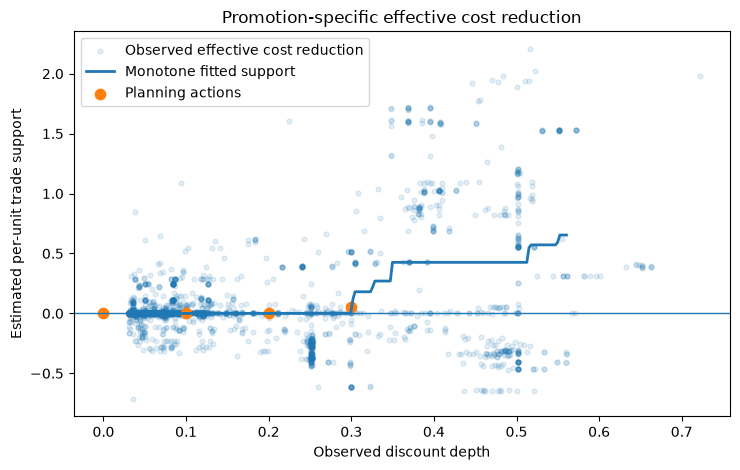

Saved: C:\Users\janza\price-of-extrapolation\results\figures\promotion_trade_support_schedule.png


In [4]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

support_plot_sample = (
    promotion_cost_sample.sample(
        n=min(
            3000,
            len(
                promotion_cost_sample
            ),
        ),
        random_state=RANDOM_SEED,
    )
    .sort_values(
        "discount_depth_model"
    )
)

ax.scatter(
    support_plot_sample[
        "discount_depth_model"
    ],
    support_plot_sample[
        "observed_support_per_unit"
    ],
    alpha=0.12,
    s=12,
    label="Observed effective cost reduction",
)

dense_depth = np.linspace(
    MIN_PROMOTION_DEPTH_FOR_SUPPORT,
    float(
        promotion_cost_sample[
            "discount_depth_model"
        ].quantile(0.99)
    ),
    200,
)

ax.plot(
    dense_depth,
    isotonic_support.predict(
        dense_depth
    ),
    linewidth=2,
    label="Monotone fitted support",
)

ax.scatter(
    support_calibration[
        "discount_depth"
    ],
    support_calibration[
        "fitted_support_per_unit"
    ],
    s=55,
    label="Planning actions",
)

ax.axhline(
    0.0,
    linewidth=1.0,
)
ax.set_xlabel(
    "Observed discount depth"
)
ax.set_ylabel(
    "Estimated per-unit trade support"
)
ax.set_title(
    "Promotion-specific effective cost reduction"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SUPPORT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", SUPPORT_FIGURE_PATH)

## 5. Break-even support diagnostics

In [5]:
weighted_parameter_mean = {
    column: float(
        np.average(
            parameter_draws[column],
            weights=parameter_draws[
                "draw_weight"
            ],
        )
    )
    for column in PARAMETER_COLUMNS
}

regular_profit = (
    REGULAR_PRICE
    - BASE_UNIT_COST
) * BASE_DEMAND

break_even_rows = []

for depth in DISCOUNT_ACTIONS:
    promotion_active = float(
        depth > 1e-12
    )

    current_demand = (
        BASE_DEMAND
        * np.power(
            max(
                1.0 - depth,
                1e-6,
            ),
            -weighted_parameter_mean[
                "price_elasticity"
            ],
        )
        * np.exp(
            weighted_parameter_mean[
                "promotion_lift_log"
            ]
            * promotion_active
        )
    )

    price = (
        REGULAR_PRICE
        * (
            1.0 - depth
        )
    )

    required_support = (
        regular_profit
        / current_demand
        - (
            price
            - BASE_UNIT_COST
        )
    )

    empirical_support = (
        SUPPORT_PER_UNIT[
            float(depth)
        ]
    )

    break_even_rows.append(
        {
            "discount_depth": float(depth),
            "predicted_current_demand": float(
                current_demand
            ),
            "regular_week_profit": float(
                regular_profit
            ),
            "required_support_to_match_regular_profit": float(
                max(
                    required_support,
                    0.0,
                )
            ),
            "empirical_support_per_unit": float(
                empirical_support
            ),
            "empirical_support_minus_break_even": float(
                empirical_support
                - max(
                    required_support,
                    0.0,
                )
            ),
            "current_profit_with_empirical_support": float(
                (
                    price
                    - BASE_UNIT_COST
                    + empirical_support
                )
                * current_demand
            ),
        }
    )

break_even_support = pd.DataFrame(
    break_even_rows
)

display(
    break_even_support
)

print(
    "The break-even calculation is one-period and "
    "therefore optimistic relative to the dynamic model."
)

,discount_depth,predicted_current_demand,regular_week_profit,required_support_to_match_regular_profit,empirical_support_per_unit,empirical_support_minus_break_even,current_profit_with_empirical_support
0,0.0,46.000000,17.89055,0.000000,0.000000,0.000000,17.890550
1,0.1,52.922500,17.89055,0.222127,0.000000,-0.222127,6.135041
2,0.2,63.831076,17.89055,0.437355,0.000000,-0.437355,-10.026266
3,0.3,78.941720,17.89055,0.656705,0.055302,-0.601403,-29.585257


The break-even calculation is one-period and therefore optimistic relative to the dynamic model.


## 6. Reduce the weighted behavioral distribution

In [6]:
theta = parameter_draws[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

original_weights = parameter_draws[
    "draw_weight"
].to_numpy(dtype=float)

theta_mean = np.average(
    theta,
    axis=0,
    weights=original_weights,
)

centered = (
    theta
    - theta_mean
)

theta_variance = np.average(
    centered ** 2,
    axis=0,
    weights=original_weights,
)

theta_scale = np.sqrt(
    theta_variance
)
theta_scale = np.where(
    theta_scale > 1e-10,
    theta_scale,
    1.0,
)

theta_standardized = (
    theta
    - theta_mean
) / theta_scale

scenario_count = min(
    MAX_DRO_SCENARIOS,
    len(parameter_draws),
)

if scenario_count == len(
    parameter_draws
):
    medoid_indices = np.arange(
        len(parameter_draws)
    )
    scenario_weights = (
        original_weights.copy()
    )
else:
    kmeans = KMeans(
        n_clusters=scenario_count,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    kmeans.fit(
        theta_standardized,
        sample_weight=original_weights,
    )

    labels = kmeans.labels_
    medoid_indices = []
    scenario_weights = []

    for cluster_id in range(
        scenario_count
    ):
        members = np.flatnonzero(
            labels == cluster_id
        )

        center = (
            kmeans.cluster_centers_[
                cluster_id
            ]
        )

        distances = np.linalg.norm(
            theta_standardized[
                members
            ]
            - center,
            axis=1,
        )

        member_weights = (
            original_weights[
                members
            ]
        )

        medoid = int(
            members[
                np.argmin(
                    distances
                )
            ]
        )

        medoid_indices.append(
            medoid
        )
        scenario_weights.append(
            float(
                member_weights.sum()
            )
        )

    medoid_indices = np.asarray(
        medoid_indices,
        dtype=int,
    )
    scenario_weights = np.asarray(
        scenario_weights,
        dtype=float,
    )

scenario_weights = (
    scenario_weights
    / scenario_weights.sum()
)

scenarios = (
    parameter_draws.iloc[
        medoid_indices
    ][PARAMETER_COLUMNS]
    .reset_index(drop=True)
)

scenarios[
    "scenario_weight"
] = scenario_weights
scenarios[
    "scenario_id"
] = np.arange(
    len(scenarios),
    dtype=int,
)

scenario_theta = scenarios[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

scenario_standardized = (
    scenario_theta
    - theta_mean
) / theta_scale

transport_cost = cdist(
    scenario_standardized,
    scenario_standardized,
    metric="euclidean",
)

print(
    "Reduced scenarios:",
    len(scenarios),
)
print(
    "Effective scenario count:",
    f"{1.0 / np.sum(scenario_weights ** 2):.2f}",
)

display(
    scenarios.head()
)

Reduced scenarios: 40
Effective scenario count: 35.20


,price_elasticity,promotion_lift_log,displacement_strength,inventory_persistence,scenario_weight,scenario_id
0,1.799866,-0.037178,0.000000,0.15,0.020000,0
1,1.699153,-0.026584,0.196363,0.60,0.025000,1
2,1.519758,-0.029099,0.344664,0.35,0.028333,2
3,1.571004,-0.002311,0.123339,0.35,0.031667,3
4,1.490037,-0.024836,0.225080,0.35,0.035000,4


## 7. Calibrate a fixed Wasserstein radius

In [7]:
def equal_weight_empirical_wasserstein(
    sample_a: np.ndarray,
    sample_b: np.ndarray,
) -> float:
    if len(sample_a) != len(sample_b):
        raise ValueError(
            "Samples must have equal cardinality."
        )

    assignment_cost = cdist(
        sample_a,
        sample_b,
        metric="euclidean",
    )

    rows, columns = (
        linear_sum_assignment(
            assignment_cost
        )
    )

    return float(
        assignment_cost[
            rows,
            columns,
        ].mean()
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

resample_size = min(
    RADIUS_RESAMPLE_SIZE,
    max(
        20,
        len(parameter_draws),
    ),
)

radius_rows = []

for replication in range(
    RADIUS_RESAMPLE_REPLICATIONS
):
    first_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=original_weights,
    )

    second_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=original_weights,
    )

    distance = (
        equal_weight_empirical_wasserstein(
            theta_standardized[
                first_indices
            ],
            theta_standardized[
                second_indices
            ],
        )
    )

    radius_rows.append(
        {
            "replication": replication,
            "wasserstein_distance": distance,
        }
    )

radius_calibration = pd.DataFrame(
    radius_rows
)

CALIBRATED_RHO = float(
    radius_calibration[
        "wasserstein_distance"
    ].quantile(
        RADIUS_QUANTILE
    )
)

RHO_VALUES = np.unique(
    np.round(
        CALIBRATED_RHO
        * RADIUS_MULTIPLIERS,
        8,
    )
)

print(
    "Calibrated rho:",
    f"{CALIBRATED_RHO:.4f}",
)
print(
    "Sensitivity radii:",
    RHO_VALUES,
)

display(
    radius_calibration[
        "wasserstein_distance"
    ].describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
        ]
    )
)

print(
    "This is an empirical instability calibration, "
    "not a formal confidence radius."
)

Calibrated rho: 0.9086
Sensitivity radii: [0.         0.45429233 0.90858466 1.362877   1.81716933]


count    100.000000
mean       0.846630
std        0.050641
min        0.706859
50%        0.844733
90%        0.908585
95%        0.924888
max        0.980684
Name: wasserstein_distance, dtype: float64

This is an empirical instability calibration, not a formal confidence radius.


## 8. Dynamic environment with trade funding

In [8]:
@dataclass(frozen=True)
class BehavioralParameters:
    price_elasticity: float
    promotion_lift_log: float
    displacement_strength: float
    inventory_persistence: float


def support_per_unit(
    discount_depth: float,
    support_scale: float,
) -> float:
    action_index = int(
        np.argmin(
            np.abs(
                DISCOUNT_ACTIONS
                - discount_depth
            )
        )
    )

    action_depth = float(
        DISCOUNT_ACTIONS[
            action_index
        ]
    )

    empirical_support = float(
        SUPPORT_PER_UNIT[
            action_depth
        ]
    )

    scaled_support = (
        float(support_scale)
        * empirical_support
    )

    return float(
        np.clip(
            scaled_support,
            0.0,
            MAX_SUPPORT_SHARE_OF_BASE_COST
            * BASE_UNIT_COST,
        )
    )


def demand_transition_profit(
    inventory: float,
    cooldown: int,
    discount_depth: float,
    parameters: BehavioralParameters,
    support_scale: float,
) -> tuple[
    float,
    float,
    int,
    float,
]:
    if (
        cooldown > 0
        and discount_depth > 1e-12
    ):
        raise ValueError(
            "A promotion was selected while cooldown was active."
        )

    price = (
        REGULAR_PRICE
        * (
            1.0
            - discount_depth
        )
    )

    promotion_active = float(
        discount_depth > 1e-12
    )

    price_multiplier = np.power(
        max(
            1.0
            - discount_depth,
            1e-6,
        ),
        -parameters.price_elasticity,
    )

    demand = (
        BASE_DEMAND
        * price_multiplier
        * np.exp(
            parameters.promotion_lift_log
            * promotion_active
            - parameters.displacement_strength
            * max(
                inventory,
                0.0,
            )
        )
    )

    next_inventory = (
        parameters.inventory_persistence
        * max(
            inventory,
            0.0,
        )
        + discount_depth
    )

    if discount_depth > 1e-12:
        next_cooldown = (
            MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
        )
    else:
        next_cooldown = max(
            int(cooldown) - 1,
            0,
        )

    trade_support = support_per_unit(
        discount_depth,
        support_scale,
    )

    unit_margin = (
        price
        - BASE_UNIT_COST
        + trade_support
    )

    profit = (
        unit_margin
        * demand
    )

    return (
        float(demand),
        float(next_inventory),
        int(next_cooldown),
        float(profit),
    )


maximum_persistence = float(
    parameter_draws[
        "inventory_persistence"
    ].max()
)

INVENTORY_MAX = (
    INVENTORY_GRID_BUFFER
    * float(
        DISCOUNT_ACTIONS.max()
    )
    / max(
        1.0
        - maximum_persistence,
        1e-3,
    )
)

INVENTORY_GRID = np.linspace(
    0.0,
    INVENTORY_MAX,
    INVENTORY_GRID_SIZE,
)

scenario_parameters = [
    BehavioralParameters(
        **{
            column: float(
                row[column]
            )
            for column in PARAMETER_COLUMNS
        }
    )
    for _, row in scenarios.iterrows()
]

evaluation_parameters = [
    BehavioralParameters(
        **{
            column: float(
                row[column]
            )
            for column in PARAMETER_COLUMNS
        }
    )
    for _, row in (
        parameter_draws.iterrows()
    )
]

evaluation_weights = (
    parameter_draws[
        "draw_weight"
    ].to_numpy(dtype=float)
)

print(
    "Inventory maximum:",
    f"{INVENTORY_MAX:.3f}",
)
print(
    "Inventory grid points:",
    len(INVENTORY_GRID),
)
print(
    "Cooldown states:",
    COOLDOWN_STATES,
)
print(
    "Discount actions:",
    DISCOUNT_ACTIONS,
)

Inventory maximum: 7.200
Inventory grid points: 61
Cooldown states: [0 1 2]
Discount actions: [0.  0.1 0.2 0.3]


## 9. Wasserstein worst-case expectation

In [9]:
def wasserstein_worst_case_expectation(
    scenario_values: np.ndarray,
    nominal_weights: np.ndarray,
    cost_matrix: np.ndarray,
    rho: float,
) -> float:
    values = np.asarray(
        scenario_values,
        dtype=float,
    )
    weights = np.asarray(
        nominal_weights,
        dtype=float,
    )

    nominal_value = float(
        np.dot(
            weights,
            values,
        )
    )

    if rho <= 1e-12:
        return nominal_value

    value_range = float(
        values.max()
        - values.min()
    )

    positive_costs = (
        cost_matrix[
            cost_matrix > 1e-12
        ]
    )

    if (
        len(positive_costs) == 0
        or value_range <= 1e-12
    ):
        return float(
            values.min()
        )

    minimum_positive_cost = float(
        positive_costs.min()
    )

    lambda_upper = (
        value_range
        / minimum_positive_cost
        + 1.0
    )

    def dual_value(
        multiplier: float,
    ) -> float:
        transported = (
            values[None, :]
            + float(multiplier)
            * cost_matrix
        )

        row_minima = (
            transported.min(
                axis=1
            )
        )

        return float(
            -float(multiplier)
            * rho
            + np.dot(
                weights,
                row_minima,
            )
        )

    result = minimize_scalar(
        lambda multiplier: -dual_value(
            float(multiplier)
        ),
        bounds=(
            0.0,
            lambda_upper,
        ),
        method="bounded",
        options={
            "xatol": 1e-8,
        },
    )

    robust_value = max(
        dual_value(0.0),
        dual_value(
            float(result.x)
        ),
        dual_value(
            lambda_upper
        ),
    )

    return float(
        np.clip(
            robust_value,
            float(
                values.min()
            ),
            nominal_value,
        )
    )


test_values = np.linspace(
    0.0,
    1.0,
    len(scenarios),
)

nominal_test = (
    wasserstein_worst_case_expectation(
        test_values,
        scenario_weights,
        transport_cost,
        rho=0.0,
    )
)

robust_test = (
    wasserstein_worst_case_expectation(
        test_values,
        scenario_weights,
        transport_cost,
        rho=CALIBRATED_RHO,
    )
)

print(
    "Nominal test value:",
    nominal_test,
)
print(
    "Robust test value:",
    robust_test,
)

if robust_test > nominal_test + 1e-8:
    raise RuntimeError(
        "Worst-case expectation exceeds nominal expectation."
    )

Nominal test value: 0.48803418803418797
Robust test value: 0.10979437329837247


## 10. Solve feedback policies

In [10]:
def feasible_actions(
    cooldown: int,
) -> np.ndarray:
    if cooldown > 0:
        return np.array(
            [0.0],
            dtype=float,
        )

    return DISCOUNT_ACTIONS


def scenario_values_for_action(
    inventory: float,
    cooldown: int,
    discount_depth: float,
    continuation_value: np.ndarray | None,
    support_scale: float,
) -> np.ndarray:
    values = []

    for parameters in (
        scenario_parameters
    ):
        (
            _,
            next_inventory,
            next_cooldown,
            profit,
        ) = demand_transition_profit(
            inventory,
            cooldown,
            discount_depth,
            parameters,
            support_scale,
        )

        if continuation_value is None:
            total = profit
        else:
            continuation = float(
                np.interp(
                    next_inventory,
                    INVENTORY_GRID,
                    continuation_value[
                        :,
                        next_cooldown,
                    ],
                )
            )

            total = (
                profit
                + DISCOUNT_FACTOR
                * continuation
            )

        values.append(
            total
        )

    return np.asarray(
        values,
        dtype=float,
    )


def solve_dynamic_policy(
    rho: float,
    support_scale: float,
) -> dict[str, np.ndarray | float]:
    value = np.zeros(
        (
            HORIZON + 1,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for time_index in range(
        HORIZON - 1,
        -1,
        -1,
    ):
        for state_index, inventory in enumerate(
            INVENTORY_GRID
        ):
            for cooldown in (
                COOLDOWN_STATES
            ):
                action_values = []

                for discount_depth in (
                    feasible_actions(
                        int(cooldown)
                    )
                ):
                    scenario_values = (
                        scenario_values_for_action(
                            inventory=float(
                                inventory
                            ),
                            cooldown=int(
                                cooldown
                            ),
                            discount_depth=float(
                                discount_depth
                            ),
                            continuation_value=value[
                                time_index + 1
                            ],
                            support_scale=float(
                                support_scale
                            ),
                        )
                    )

                    robust_value = (
                        wasserstein_worst_case_expectation(
                            scenario_values,
                            scenario_weights,
                            transport_cost,
                            rho=float(rho),
                        )
                    )

                    action_values.append(
                        (
                            robust_value,
                            float(
                                discount_depth
                            ),
                        )
                    )

                best_value, best_action = max(
                    action_values,
                    key=lambda item: (
                        item[0],
                        -item[1],
                    ),
                )

                value[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_value

                policy[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_action

    return {
        "rho": float(rho),
        "support_scale": float(
            support_scale
        ),
        "value": value,
        "policy": policy,
    }


def solve_myopic_policy(
    support_scale: float,
) -> np.ndarray:
    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for state_index, inventory in enumerate(
        INVENTORY_GRID
    ):
        for cooldown in (
            COOLDOWN_STATES
        ):
            action_values = []

            for discount_depth in (
                feasible_actions(
                    int(cooldown)
                )
            ):
                scenario_values = (
                    scenario_values_for_action(
                        inventory=float(
                            inventory
                        ),
                        cooldown=int(
                            cooldown
                        ),
                        discount_depth=float(
                            discount_depth
                        ),
                        continuation_value=None,
                        support_scale=float(
                            support_scale
                        ),
                    )
                )

                action_values.append(
                    (
                        float(
                            np.dot(
                                scenario_weights,
                                scenario_values,
                            )
                        ),
                        float(
                            discount_depth
                        ),
                    )
                )

            _, best_action = max(
                action_values,
                key=lambda item: (
                    item[0],
                    -item[1],
                ),
            )

            policy[
                :,
                state_index,
                cooldown,
            ] = best_action

    return policy


main_rho = float(
    RHO_VALUES[
        np.argmin(
            np.abs(
                RHO_VALUES
                - CALIBRATED_RHO
            )
        )
    ]
)

solution_keys = set()

for rho in RHO_VALUES:
    solution_keys.add(
        (
            MAIN_SUPPORT_SCALE,
            float(rho),
        )
    )

for support_scale in (
    SUPPORT_SCALE_GRID
):
    solution_keys.add(
        (
            float(support_scale),
            0.0,
        )
    )
    solution_keys.add(
        (
            float(support_scale),
            main_rho,
        )
    )

dynamic_solutions = {
    key: solve_dynamic_policy(
        rho=key[1],
        support_scale=key[0],
    )
    for key in sorted(
        solution_keys
    )
}

myopic_policies = {
    float(support_scale): (
        solve_myopic_policy(
            float(
                support_scale
            )
        )
    )
    for support_scale in (
        SUPPORT_SCALE_GRID
    )
}

no_promotion_policy = np.zeros(
    (
        HORIZON,
        INVENTORY_GRID_SIZE,
        len(COOLDOWN_STATES),
    ),
    dtype=float,
)

print(
    "Dynamic policy solutions:",
    len(dynamic_solutions),
)
print(
    "Main calibrated rho:",
    main_rho,
)

Dynamic policy solutions: 13
Main calibrated rho: 0.90858466


## 11. Oracle evaluation under fixed behavioral DGPs

In [11]:
def nearest_inventory_index(
    inventory: float,
) -> int:
    return int(
        np.argmin(
            np.abs(
                INVENTORY_GRID
                - inventory
            )
        )
    )


def evaluate_policy(
    policy: np.ndarray,
    parameters: BehavioralParameters,
    support_scale: float,
    initial_inventory: float = INITIAL_INVENTORY,
    initial_cooldown: int = INITIAL_COOLDOWN,
) -> dict[str, object]:
    inventory = float(
        initial_inventory
    )
    cooldown = int(
        initial_cooldown
    )
    total_profit = 0.0

    discount_path = []
    inventory_path = [
        inventory
    ]
    cooldown_path = [
        cooldown
    ]
    demand_path = []
    profit_path = []
    support_path = []

    for time_index in range(
        HORIZON
    ):
        state_index = (
            nearest_inventory_index(
                inventory
            )
        )

        discount_depth = float(
            policy[
                time_index,
                state_index,
                cooldown,
            ]
        )

        (
            demand,
            next_inventory,
            next_cooldown,
            profit,
        ) = demand_transition_profit(
            inventory,
            cooldown,
            discount_depth,
            parameters,
            support_scale,
        )

        total_profit += (
            DISCOUNT_FACTOR
            ** time_index
        ) * profit

        discount_path.append(
            discount_depth
        )
        inventory_path.append(
            next_inventory
        )
        cooldown_path.append(
            next_cooldown
        )
        demand_path.append(
            demand
        )
        profit_path.append(
            profit
        )
        support_path.append(
            support_per_unit(
                discount_depth,
                support_scale,
            )
        )

        inventory = float(
            np.clip(
                next_inventory,
                0.0,
                INVENTORY_MAX,
            )
        )
        cooldown = int(
            next_cooldown
        )

    positive_discounts = [
        depth
        for depth in discount_path
        if depth > 1e-12
    ]

    return {
        "discounted_profit": float(
            total_profit
        ),
        "promotion_count": int(
            len(
                positive_discounts
            )
        ),
        "mean_promotion_depth": (
            float(
                np.mean(
                    positive_discounts
                )
            )
            if positive_discounts
            else 0.0
        ),
        "discount_path": (
            discount_path
        ),
        "inventory_path": (
            inventory_path
        ),
        "cooldown_path": (
            cooldown_path
        ),
        "demand_path": (
            demand_path
        ),
        "profit_path": (
            profit_path
        ),
        "support_path": (
            support_path
        ),
    }


def solve_oracle_policy(
    parameters: BehavioralParameters,
    support_scale: float,
) -> np.ndarray:
    value = np.zeros(
        (
            HORIZON + 1,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    policy = np.zeros(
        (
            HORIZON,
            INVENTORY_GRID_SIZE,
            len(COOLDOWN_STATES),
        ),
        dtype=float,
    )

    for time_index in range(
        HORIZON - 1,
        -1,
        -1,
    ):
        for state_index, inventory in enumerate(
            INVENTORY_GRID
        ):
            for cooldown in (
                COOLDOWN_STATES
            ):
                action_values = []

                for discount_depth in (
                    feasible_actions(
                        int(cooldown)
                    )
                ):
                    (
                        _,
                        next_inventory,
                        next_cooldown,
                        profit,
                    ) = demand_transition_profit(
                        float(
                            inventory
                        ),
                        int(
                            cooldown
                        ),
                        float(
                            discount_depth
                        ),
                        parameters,
                        float(
                            support_scale
                        ),
                    )

                    continuation = float(
                        np.interp(
                            next_inventory,
                            INVENTORY_GRID,
                            value[
                                time_index + 1,
                                :,
                                next_cooldown,
                            ],
                        )
                    )

                    action_values.append(
                        (
                            profit
                            + DISCOUNT_FACTOR
                            * continuation,
                            float(
                                discount_depth
                            ),
                        )
                    )

                best_value, best_action = max(
                    action_values,
                    key=lambda item: (
                        item[0],
                        -item[1],
                    ),
                )

                value[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_value

                policy[
                    time_index,
                    state_index,
                    cooldown,
                ] = best_action

    return policy


evaluation_rows = []

for support_scale in (
    SUPPORT_SCALE_GRID
):
    support_scale = float(
        support_scale
    )

    policies_for_scale = {
        "no_promotion": (
            no_promotion_policy
        ),
        "myopic": (
            myopic_policies[
                support_scale
            ]
        ),
        "nominal_dynamic": (
            dynamic_solutions[
                (
                    support_scale,
                    0.0,
                )
            ][
                "policy"
            ]
        ),
        "dro_calibrated": (
            dynamic_solutions[
                (
                    support_scale,
                    main_rho,
                )
            ][
                "policy"
            ]
        ),
    }

    if np.isclose(
        support_scale,
        MAIN_SUPPORT_SCALE,
    ):
        for rho in (
            RHO_VALUES
        ):
            policies_for_scale[
                f"dro_rho_{float(rho):.6f}"
            ] = (
                dynamic_solutions[
                    (
                        support_scale,
                        float(
                            rho
                        ),
                    )
                ][
                    "policy"
                ]
            )

    for draw_index, parameters in enumerate(
        evaluation_parameters
    ):
        oracle_policy = (
            solve_oracle_policy(
                parameters,
                support_scale,
            )
        )

        oracle_result = (
            evaluate_policy(
                oracle_policy,
                parameters,
                support_scale,
            )
        )

        oracle_profit = float(
            oracle_result[
                "discounted_profit"
            ]
        )

        for policy_name, policy in (
            policies_for_scale.items()
        ):
            result = evaluate_policy(
                policy,
                parameters,
                support_scale,
            )

            evaluation_rows.append(
                {
                    "draw_index": (
                        draw_index
                    ),
                    "draw_weight": float(
                        evaluation_weights[
                            draw_index
                        ]
                    ),
                    "support_scale": (
                        support_scale
                    ),
                    "policy": (
                        policy_name
                    ),
                    "discounted_profit": (
                        result[
                            "discounted_profit"
                        ]
                    ),
                    "oracle_profit": (
                        oracle_profit
                    ),
                    "regret": (
                        oracle_profit
                        - result[
                            "discounted_profit"
                        ]
                    ),
                    "promotion_count": (
                        result[
                            "promotion_count"
                        ]
                    ),
                    "mean_promotion_depth": (
                        result[
                            "mean_promotion_depth"
                        ]
                    ),
                    "price_elasticity": (
                        parameters.price_elasticity
                    ),
                    "promotion_lift_log": (
                        parameters.promotion_lift_log
                    ),
                    "displacement_strength": (
                        parameters.displacement_strength
                    ),
                    "inventory_persistence": (
                        parameters.inventory_persistence
                    ),
                }
            )

policy_evaluation = pd.DataFrame(
    evaluation_rows
)

policy_evaluation[
    "displacement_burden"
] = (
    policy_evaluation[
        "displacement_strength"
    ]
    / (
        1.0
        - policy_evaluation[
            "inventory_persistence"
        ]
    ).clip(
        lower=1e-6
    )
)

print(
    "Evaluation rows:",
    f"{len(policy_evaluation):,}",
)

Evaluation rows: 14,100


## 12. Weighted policy summaries

In [12]:
def weighted_mean(
    values: np.ndarray,
    weights: np.ndarray,
) -> float:
    return float(
        np.average(
            values,
            weights=weights,
        )
    )


def weighted_quantile(
    values: np.ndarray,
    weights: np.ndarray,
    quantile: float,
) -> float:
    order = np.argsort(
        values
    )

    ordered_values = values[
        order
    ]
    ordered_weights = weights[
        order
    ]

    cumulative = np.cumsum(
        ordered_weights
    )
    cumulative = (
        cumulative
        / cumulative[-1]
    )

    return float(
        np.interp(
            quantile,
            cumulative,
            ordered_values,
        )
    )


summary_rows = []

for (
    support_scale,
    policy_name,
), group in policy_evaluation.groupby(
    [
        "support_scale",
        "policy",
    ],
    observed=True,
):
    weights = group[
        "draw_weight"
    ].to_numpy(dtype=float)

    profit = group[
        "discounted_profit"
    ].to_numpy(dtype=float)

    regret = group[
        "regret"
    ].to_numpy(dtype=float)

    promotion_count = group[
        "promotion_count"
    ].to_numpy(dtype=float)

    promotion_depth = group[
        "mean_promotion_depth"
    ].to_numpy(dtype=float)

    summary_rows.append(
        {
            "support_scale": float(
                support_scale
            ),
            "policy": str(
                policy_name
            ),
            "mean_profit": (
                weighted_mean(
                    profit,
                    weights,
                )
            ),
            "p10_profit": (
                weighted_quantile(
                    profit,
                    weights,
                    0.10,
                )
            ),
            "worst_profit": float(
                profit.min()
            ),
            "mean_regret": (
                weighted_mean(
                    regret,
                    weights,
                )
            ),
            "p90_regret": (
                weighted_quantile(
                    regret,
                    weights,
                    0.90,
                )
            ),
            "maximum_regret": float(
                regret.max()
            ),
            "mean_promotion_count": (
                weighted_mean(
                    promotion_count,
                    weights,
                )
            ),
            "mean_promotion_depth": (
                weighted_mean(
                    promotion_depth,
                    weights,
                )
            ),
            "promotes_in_any_DGP_share": (
                weighted_mean(
                    (
                        promotion_count
                        > 0
                    ).astype(float),
                    weights,
                )
            ),
        }
    )

policy_summary = pd.DataFrame(
    summary_rows
)

main_summary = policy_summary.loc[
    np.isclose(
        policy_summary[
            "support_scale"
        ],
        MAIN_SUPPORT_SCALE,
    )
    & policy_summary[
        "policy"
    ].isin(
        [
            "no_promotion",
            "myopic",
            "nominal_dynamic",
            "dro_calibrated",
        ]
    )
].copy()

display(
    main_summary.sort_values(
        [
            "maximum_regret",
            "mean_regret",
        ]
    )
)

degenerate_main = (
    main_summary[
        "mean_promotion_count"
    ]
    .fillna(0.0)
    .le(1e-12)
    .all()
)

print(
    "All main policies avoid promotions:",
    degenerate_main,
)

if degenerate_main:
    warnings.warn(
        "The empirical trade-support schedule is still "
        "insufficient to make promotions optimal. "
        "Interpret the support-scale sensitivity as a "
        "break-even exercise rather than a policy comparison."
    )

,support_scale,policy,mean_profit,p10_profit,worst_profit,mean_regret,p90_regret,maximum_regret,mean_promotion_count,mean_promotion_depth,promotes_in_any_DGP_share
8,1.0,dro_calibrated,208.880018,208.880018,208.880018,0.0,0.0,0.0,0.0,0.0,0.0
14,1.0,myopic,208.880018,208.880018,208.880018,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,no_promotion,208.880018,208.880018,208.880018,0.0,0.0,0.0,0.0,0.0,0.0
16,1.0,nominal_dynamic,208.880018,208.880018,208.880018,0.0,0.0,0.0,0.0,0.0,0.0


All main policies avoid promotions: True


C:\Users\janza\AppData\Local\Temp\ipykernel_15828\2760345721.py:189: UserWarning: The empirical trade-support schedule is still insufficient to make promotions optimal. Interpret the support-scale sensitivity as a break-even exercise rather than a policy comparison.
  warnings.warn(


## 13. Technology-value decomposition

In [13]:
main_evaluation = (
    policy_evaluation.loc[
        np.isclose(
            policy_evaluation[
                "support_scale"
            ],
            MAIN_SUPPORT_SCALE,
        )
        & policy_evaluation[
            "policy"
        ].isin(
            [
                "myopic",
                "nominal_dynamic",
                "dro_calibrated",
            ]
        )
    ][
        [
            "draw_index",
            "draw_weight",
            "policy",
            "discounted_profit",
            "regret",
            "promotion_count",
            "mean_promotion_depth",
        ]
    ]
    .pivot(
        index=[
            "draw_index",
            "draw_weight",
        ],
        columns="policy",
        values=[
            "discounted_profit",
            "regret",
            "promotion_count",
            "mean_promotion_depth",
        ],
    )
)

main_evaluation.columns = [
    f"{metric}__{policy}"
    for metric, policy
    in main_evaluation.columns
]

main_evaluation = (
    main_evaluation.reset_index()
)

main_evaluation[
    "value_of_dynamic_optimization"
] = (
    main_evaluation[
        "discounted_profit__nominal_dynamic"
    ]
    - main_evaluation[
        "discounted_profit__myopic"
    ]
)

main_evaluation[
    "value_of_robustness"
] = (
    main_evaluation[
        "discounted_profit__dro_calibrated"
    ]
    - main_evaluation[
        "discounted_profit__nominal_dynamic"
    ]
)

main_evaluation[
    "regret_reduction_from_robustness"
] = (
    main_evaluation[
        "regret__nominal_dynamic"
    ]
    - main_evaluation[
        "regret__dro_calibrated"
    ]
)

technology_rows = []

for metric in [
    "value_of_dynamic_optimization",
    "value_of_robustness",
    "regret_reduction_from_robustness",
]:
    values = main_evaluation[
        metric
    ].to_numpy(dtype=float)

    weights = main_evaluation[
        "draw_weight"
    ].to_numpy(dtype=float)

    technology_rows.append(
        {
            "metric": metric,
            "weighted_mean": (
                weighted_mean(
                    values,
                    weights,
                )
            ),
            "weighted_p10": (
                weighted_quantile(
                    values,
                    weights,
                    0.10,
                )
            ),
            "weighted_median": (
                weighted_quantile(
                    values,
                    weights,
                    0.50,
                )
            ),
            "weighted_p90": (
                weighted_quantile(
                    values,
                    weights,
                    0.90,
                )
            ),
            "positive_share": (
                weighted_mean(
                    (
                        values > 0
                    ).astype(float),
                    weights,
                )
            ),
        }
    )

technology_value = pd.DataFrame(
    technology_rows
)

display(
    technology_value
)

,metric,weighted_mean,weighted_p10,weighted_median,weighted_p90,positive_share
0,value_of_dynamic_optimization,0.0,0.0,0.0,0.0,0.0
1,value_of_robustness,0.0,0.0,0.0,0.0,0.0
2,regret_reduction_from_robustness,0.0,0.0,0.0,0.0,0.0


## 14. Sensitivity to manufacturer support

,support_scale,policy,mean_profit,p10_profit,maximum_regret,mean_promotion_count,mean_promotion_depth,promotes_in_any_DGP_share
0,0.0,dro_calibrated,208.880018,208.880018,0.0,0.0,0.0,0.0
1,0.5,dro_calibrated,208.880018,208.880018,0.0,0.0,0.0,0.0
2,1.0,dro_calibrated,208.880018,208.880018,0.0,0.0,0.0,0.0
3,1.5,dro_calibrated,208.880018,208.880018,0.0,0.0,0.0,0.0
4,2.0,dro_calibrated,208.880018,208.880018,0.0,0.0,0.0,0.0
5,0.0,myopic,208.880018,208.880018,0.0,0.0,0.0,0.0
6,0.5,myopic,208.880018,208.880018,0.0,0.0,0.0,0.0
7,1.0,myopic,208.880018,208.880018,0.0,0.0,0.0,0.0
8,1.5,myopic,208.880018,208.880018,0.0,0.0,0.0,0.0
9,2.0,myopic,208.880018,208.880018,0.0,0.0,0.0,0.0


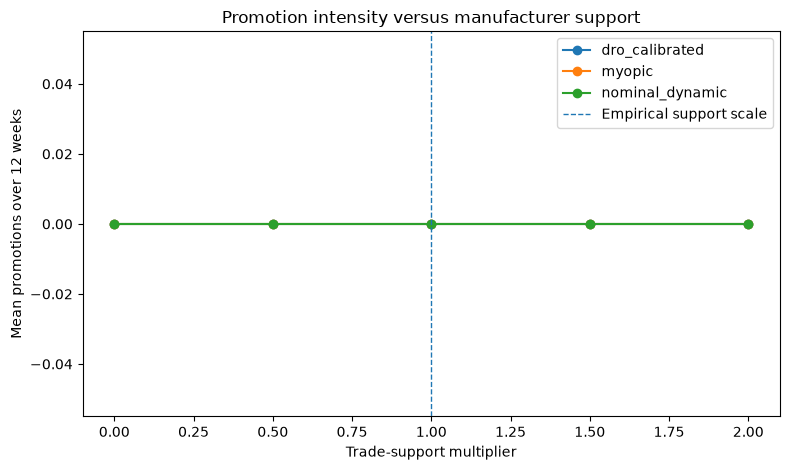

Saved: C:\Users\janza\price-of-extrapolation\results\figures\promotion_support_sensitivity.png


In [14]:
support_sensitivity = (
    policy_summary.loc[
        policy_summary[
            "policy"
        ].isin(
            [
                "myopic",
                "nominal_dynamic",
                "dro_calibrated",
            ]
        )
    ]
    .sort_values(
        [
            "policy",
            "support_scale",
        ]
    )
    .reset_index(drop=True)
)

display(
    support_sensitivity[
        [
            "support_scale",
            "policy",
            "mean_profit",
            "p10_profit",
            "maximum_regret",
            "mean_promotion_count",
            "mean_promotion_depth",
            "promotes_in_any_DGP_share",
        ]
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 4.8)
)

for policy_name, group in (
    support_sensitivity.groupby(
        "policy",
        observed=True,
    )
):
    ax.plot(
        group[
            "support_scale"
        ],
        group[
            "mean_promotion_count"
        ],
        marker="o",
        label=policy_name,
    )

ax.axvline(
    MAIN_SUPPORT_SCALE,
    linestyle="--",
    linewidth=1.0,
    label="Empirical support scale",
)
ax.set_xlabel(
    "Trade-support multiplier"
)
ax.set_ylabel(
    "Mean promotions over 12 weeks"
)
ax.set_title(
    "Promotion intensity versus manufacturer support"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    SUPPORT_SENSITIVITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    SUPPORT_SENSITIVITY_FIGURE_PATH,
)

## 15. Sensitivity to the DRO radius

,rho,mean_profit,p10_profit,maximum_regret,mean_regret,mean_promotion_count,mean_promotion_depth
0,0.000000,208.880018,208.880018,0.0,0.0,0.0,0.0
1,0.454292,208.880018,208.880018,0.0,0.0,0.0,0.0
2,0.908585,208.880018,208.880018,0.0,0.0,0.0,0.0
3,1.362877,208.880018,208.880018,0.0,0.0,0.0,0.0
4,1.817169,208.880018,208.880018,0.0,0.0,0.0,0.0


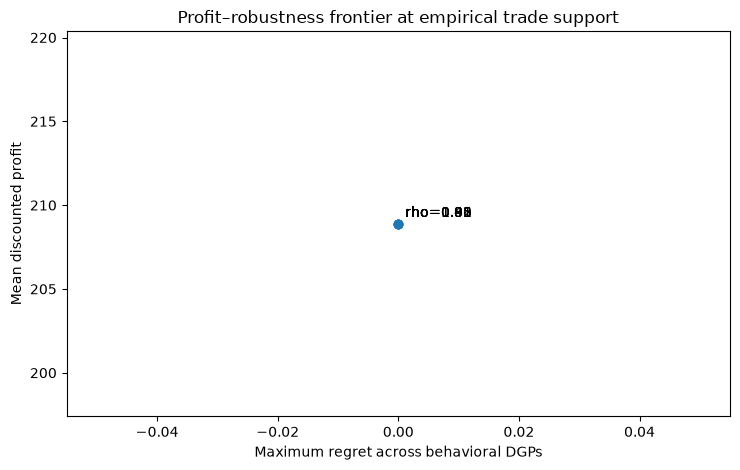

Saved: C:\Users\janza\price-of-extrapolation\results\figures\promotion_rho_frontier_with_funding.png


In [15]:
rho_frontier_rows = []

for rho in RHO_VALUES:
    policy_name = (
        f"dro_rho_{float(rho):.6f}"
    )

    row = policy_summary.loc[
        np.isclose(
            policy_summary[
                "support_scale"
            ],
            MAIN_SUPPORT_SCALE,
        )
        & policy_summary[
            "policy"
        ].eq(
            policy_name
        )
    ]

    if row.empty:
        continue

    rho_frontier_rows.append(
        {
            "rho": float(rho),
            "mean_profit": float(
                row.iloc[0][
                    "mean_profit"
                ]
            ),
            "p10_profit": float(
                row.iloc[0][
                    "p10_profit"
                ]
            ),
            "maximum_regret": float(
                row.iloc[0][
                    "maximum_regret"
                ]
            ),
            "mean_regret": float(
                row.iloc[0][
                    "mean_regret"
                ]
            ),
            "mean_promotion_count": float(
                row.iloc[0][
                    "mean_promotion_count"
                ]
            ),
            "mean_promotion_depth": float(
                row.iloc[0][
                    "mean_promotion_depth"
                ]
            ),
        }
    )

rho_frontier = (
    pd.DataFrame(
        rho_frontier_rows
    )
    .sort_values(
        "rho"
    )
)

display(
    rho_frontier
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)

ax.plot(
    rho_frontier[
        "maximum_regret"
    ],
    rho_frontier[
        "mean_profit"
    ],
    marker="o",
)

for row in rho_frontier.itertuples(
    index=False
):
    ax.annotate(
        f"rho={row.rho:.2f}",
        (
            row.maximum_regret,
            row.mean_profit,
        ),
        textcoords="offset points",
        xytext=(5, 5),
    )

ax.set_xlabel(
    "Maximum regret across behavioral DGPs"
)
ax.set_ylabel(
    "Mean discounted profit"
)
ax.set_title(
    "Profit–robustness frontier at empirical trade support"
)
fig.tight_layout()
fig.savefig(
    RHO_FRONTIER_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    RHO_FRONTIER_FIGURE_PATH,
)

## 16. Policy monotonicity and nondegeneracy diagnostics

In [16]:
diagnostic_rows = []

policies_to_diagnose = {
    "myopic": (
        myopic_policies[
            MAIN_SUPPORT_SCALE
        ]
    ),
    "nominal_dynamic": (
        dynamic_solutions[
            (
                MAIN_SUPPORT_SCALE,
                0.0,
            )
        ][
            "policy"
        ]
    ),
    "dro_calibrated": (
        dynamic_solutions[
            (
                MAIN_SUPPORT_SCALE,
                main_rho,
            )
        ][
            "policy"
        ]
    ),
}

for policy_name, policy in (
    policies_to_diagnose.items()
):
    inventory_violations = 0
    inventory_comparisons = 0

    for time_index in range(
        HORIZON
    ):
        for cooldown in (
            COOLDOWN_STATES
        ):
            increases = (
                np.diff(
                    policy[
                        time_index,
                        :,
                        cooldown,
                    ]
                )
                > 1e-12
            )

            inventory_violations += int(
                increases.sum()
            )
            inventory_comparisons += int(
                len(increases)
            )

    initial_state_actions = (
        policy[
            :,
            nearest_inventory_index(
                INITIAL_INVENTORY
            ),
            INITIAL_COOLDOWN,
        ]
    )

    diagnostic_rows.append(
        {
            "policy": policy_name,
            "inventory_monotonicity_violations": (
                inventory_violations
            ),
            "inventory_comparisons": (
                inventory_comparisons
            ),
            "violation_share": (
                inventory_violations
                / inventory_comparisons
            ),
            "unique_actions": int(
                np.unique(
                    policy
                ).size
            ),
            "initial_state_promotion_opportunities": int(
                np.sum(
                    initial_state_actions
                    > 1e-12
                )
            ),
            "maximum_selected_discount": float(
                policy.max()
            ),
        }
    )

policy_diagnostics = pd.DataFrame(
    diagnostic_rows
)

display(
    policy_diagnostics
)

print(
    "A monotonicity violation means the recommended "
    "discount becomes deeper as the displacement stock rises."
)
print(
    "Policy actions need not vary monotonically with rho; "
    "the radius frontier reports realized policy changes "
    "rather than assuming such ordering."
)

,policy,inventory_monotonicity_violations,inventory_comparisons,violation_share,unique_actions,initial_state_promotion_opportunities,maximum_selected_discount
0,myopic,0,2160,0.0,1,0,0.0
1,nominal_dynamic,0,2160,0.0,1,0,0.0
2,dro_calibrated,0,2160,0.0,1,0,0.0


A monotonicity violation means the recommended discount becomes deeper as the displacement stock rises.
Policy actions need not vary monotonically with rho; the radius frontier reports realized policy changes rather than assuming such ordering.


## 17. Representative promotion paths

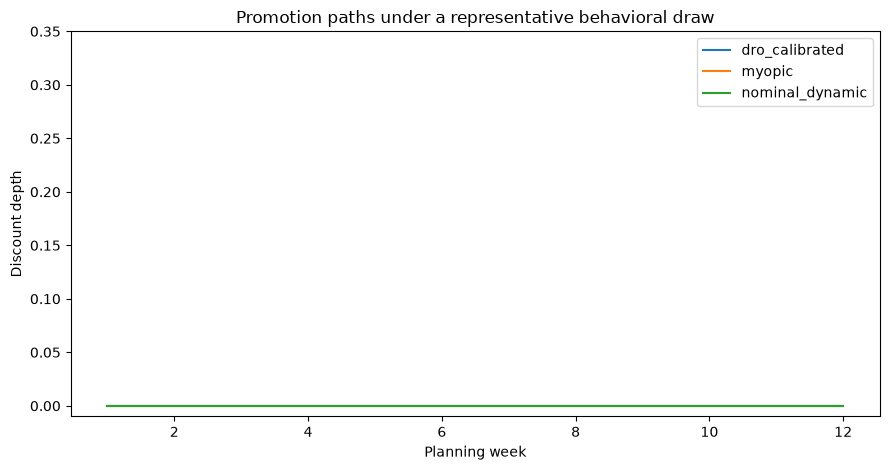

,policy,week,discount_depth,displacement_state_before,trade_support_per_unit,weekly_profit
0,myopic,1,0.0,0.0,0.0,17.89055
1,myopic,2,0.0,0.0,0.0,17.89055
2,myopic,3,0.0,0.0,0.0,17.89055
3,myopic,4,0.0,0.0,0.0,17.89055
4,myopic,5,0.0,0.0,0.0,17.89055
5,myopic,6,0.0,0.0,0.0,17.89055
6,myopic,7,0.0,0.0,0.0,17.89055
7,myopic,8,0.0,0.0,0.0,17.89055
8,myopic,9,0.0,0.0,0.0,17.89055
9,myopic,10,0.0,0.0,0.0,17.89055


Saved: C:\Users\janza\price-of-extrapolation\results\figures\promotion_policy_paths_with_funding.png


In [17]:
representative_draw_position = int(
    np.argmin(
        np.abs(
            parameter_draws[
                "displacement_strength"
            ]
            - parameter_draws[
                "displacement_strength"
            ].median()
        )
        + np.abs(
            parameter_draws[
                "inventory_persistence"
            ]
            - parameter_draws[
                "inventory_persistence"
            ].median()
        )
    )
)

representative_parameters = (
    evaluation_parameters[
        representative_draw_position
    ]
)

representative_policies = {
    "myopic": (
        policies_to_diagnose[
            "myopic"
        ]
    ),
    "nominal_dynamic": (
        policies_to_diagnose[
            "nominal_dynamic"
        ]
    ),
    "dro_calibrated": (
        policies_to_diagnose[
            "dro_calibrated"
        ]
    ),
}

path_rows = []

for policy_name, policy in (
    representative_policies.items()
):
    result = evaluate_policy(
        policy,
        representative_parameters,
        MAIN_SUPPORT_SCALE,
    )

    for week_index, depth in enumerate(
        result[
            "discount_path"
        ],
        start=1,
    ):
        path_rows.append(
            {
                "policy": (
                    policy_name
                ),
                "week": (
                    week_index
                ),
                "discount_depth": (
                    depth
                ),
                "displacement_state_before": (
                    result[
                        "inventory_path"
                    ][
                        week_index - 1
                    ]
                ),
                "trade_support_per_unit": (
                    result[
                        "support_path"
                    ][
                        week_index - 1
                    ]
                ),
                "weekly_profit": (
                    result[
                        "profit_path"
                    ][
                        week_index - 1
                    ]
                ),
            }
        )

representative_paths = pd.DataFrame(
    path_rows
)

fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

for policy_name, group in (
    representative_paths.groupby(
        "policy",
        observed=True,
    )
):
    ax.step(
        group[
            "week"
        ],
        group[
            "discount_depth"
        ],
        where="mid",
        label=policy_name,
    )

ax.set_xlabel(
    "Planning week"
)
ax.set_ylabel(
    "Discount depth"
)
ax.set_ylim(
    -0.01,
    float(
        DISCOUNT_ACTIONS.max()
    )
    + 0.05,
)
ax.set_title(
    "Promotion paths under a representative behavioral draw"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PATH_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

display(
    representative_paths
)

print(
    "Saved:",
    PATH_FIGURE_PATH,
)

## 18. Save outputs

In [18]:
policy_artifact = {
    "inventory_grid": (
        INVENTORY_GRID
    ),
    "cooldown_states": (
        COOLDOWN_STATES
    ),
    "discount_actions": (
        DISCOUNT_ACTIONS
    ),
    "support_per_unit": (
        SUPPORT_PER_UNIT
    ),
    "support_scale_grid": (
        SUPPORT_SCALE_GRID
    ),
    "main_support_scale": (
        MAIN_SUPPORT_SCALE
    ),
    "horizon": (
        HORIZON
    ),
    "discount_factor": (
        DISCOUNT_FACTOR
    ),
    "calibrated_rho": (
        CALIBRATED_RHO
    ),
    "rho_values": (
        RHO_VALUES
    ),
    "dynamic_solutions": (
        dynamic_solutions
    ),
    "myopic_policies": (
        myopic_policies
    ),
}

pd.to_pickle(
    policy_artifact,
    POLICY_OUTPUT_PATH,
)

policy_evaluation.to_pickle(
    EVALUATION_OUTPUT_PATH
)

support_calibration.to_csv(
    SUPPORT_CALIBRATION_PATH,
    index=False,
)

break_even_support.to_csv(
    BREAK_EVEN_SUPPORT_PATH,
    index=False,
)

policy_summary.to_csv(
    POLICY_SUMMARY_PATH,
    index=False,
)

technology_value.to_csv(
    TECHNOLOGY_VALUE_PATH,
    index=False,
)

support_sensitivity.to_csv(
    SUPPORT_SENSITIVITY_PATH,
    index=False,
)

rho_frontier.to_csv(
    RHO_FRONTIER_PATH,
    index=False,
)

scenarios.to_csv(
    SCENARIO_PATH,
    index=False,
)

radius_calibration.to_csv(
    RADIUS_PATH,
    index=False,
)

configuration = {
    "horizon": int(
        HORIZON
    ),
    "discount_factor": float(
        DISCOUNT_FACTOR
    ),
    "discount_actions": (
        DISCOUNT_ACTIONS.tolist()
    ),
    "minimum_nonpromotion_weeks_after_promotion": int(
        MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
    ),
    "main_support_scale": float(
        MAIN_SUPPORT_SCALE
    ),
    "support_scale_grid": (
        SUPPORT_SCALE_GRID.tolist()
    ),
    "support_schedule": {
        str(depth): float(
            support
        )
        for depth, support in (
            SUPPORT_PER_UNIT.items()
        )
    },
    "support_calibration": (
        "same_upc_week_nonpromotion_cost_benchmark_"
        "with_panel_product_and_global_fallbacks"
    ),
    "inventory_grid_size": int(
        INVENTORY_GRID_SIZE
    ),
    "inventory_max": float(
        INVENTORY_MAX
    ),
    "dro_scenarios": int(
        len(scenarios)
    ),
    "radius_resample_replications": int(
        RADIUS_RESAMPLE_REPLICATIONS
    ),
    "radius_resample_size": int(
        resample_size
    ),
    "radius_quantile": float(
        RADIUS_QUANTILE
    ),
    "calibrated_rho": float(
        CALIBRATED_RHO
    ),
    "rho_values": (
        RHO_VALUES.tolist()
    ),
    "ambiguity_geometry": (
        "finite_support_wasserstein_1_"
        "rectangular_by_period"
    ),
    "behavioral_model": (
        "Q0*(1-d)^(-epsilon)*"
        "exp(gamma*1[d>0]-psi*I);"
        "I_next=r*I+d"
    ),
    "profit_model": (
        "(regular_price*(1-d)-base_cost+"
        "support_scale*s(d))*Q"
    ),
    "economic_interpretation": (
        "manufacturer_trade_support_is_a_contract_input;"
        "DRO_is_only_over_behavioral_parameters"
    ),
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Saved policies:",
    POLICY_OUTPUT_PATH,
)
print(
    "Saved evaluation:",
    EVALUATION_OUTPUT_PATH,
)
print(
    "Saved policy summary:",
    POLICY_SUMMARY_PATH,
)
print(
    "Saved configuration:",
    CONFIGURATION_PATH,
)

Saved policies: C:\Users\janza\price-of-extrapolation\data\processed\dro_promotion_policies_with_funding.pkl
Saved evaluation: C:\Users\janza\price-of-extrapolation\data\processed\dro_promotion_evaluation_with_funding.pkl
Saved policy summary: C:\Users\janza\price-of-extrapolation\results\tables\dro_promotion_policy_summary_with_funding.csv
Saved configuration: C:\Users\janza\price-of-extrapolation\results\models\dro_promotion_planning_with_funding_configuration.json


## Interpretation checklist

The revised model is informative only when the following are reported
transparently:

1. **Trade-support credibility:** the fitted support schedule must be
   compared with raw promotional cost differences and neighborhood
   medians.
2. **Break-even economics:** empirical support should be compared with
   the one-period support required to match regular-price profit.
3. **Nondegeneracy:** an all-zero promotion policy is an economic result,
   not something to hide. In that case, the support-scale analysis is a
   break-even exercise.
4. **Mechanism:** the dynamic penalty is supported mainly for deep
   promotions and is only weakly persistent.
5. **Technology comparison:** the value of dynamic optimization and the
   value of robustness must be reported separately.
6. **No methods soup:** trade support is not placed inside the ambiguity
   set in the main specification.
7. **Radius behavior:** promotion depth need not vary monotonically with
   \(\rho\); realized policy changes are diagnosed rather than assumed.
8. **Counterfactual status:** all profit results are model-based and are
   not realized causal effects from the scanner data.